# 01 - Exploratory data analysis
NASA near-Earth-object close approaches (Kaggle). Goal: understand what separates **Potentially Hazardous Asteroids (PHAs)** before modelling.

PHA = orbit passes within 0.05 AU of Earth's **and** absolute magnitude H <= 22 (> ~140 m).

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.clean import load_raw, clean, class_balance, diameter_h_formula_error
from src.features import add_features
sns.set_theme(style='whitegrid')
raw = load_raw(); df = clean(raw)
print(raw.shape, '->', df.shape)
df.head()

(90836, 10) -> (90836, 9)


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous,asteroid
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,16.73,0,162635 (2000 SS164)
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,20.00,1,277475 (2005 WK4)
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,17.83,0,512244 (2015 YE18)
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,22.20,0,(2012 BV13)
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,20.09,1,(2014 GE35)


## 1. Structure of the data
Each row is one **close approach**, not one asteroid, so an asteroid can appear many times. We therefore split train/test *by asteroid* later. Two columns are constant (`orbiting_body`, `sentry_object`) and were dropped; there are no missing values.

In [2]:
print('rows:', len(df), '| unique asteroids:', df['asteroid'].nunique())
print('approaches per asteroid:'); print(df.groupby('asteroid').size().describe().round(2))
df.describe().T

rows: 90836 | unique asteroids: 27423
approaches per asteroid:
count    27423.00
mean         3.31
std          3.41
min          1.00
25%          1.00
50%          2.00
75%          4.00
max         43.00
dtype: float64


,count,mean,std,min,25%,50%,75%,max
id,90836.0,1.438288e+07,2.087202e+07,2.000433e+06,3.448110e+06,3.748362e+06,3.884023e+06,5.427591e+07
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,6.089126e-04,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,1.361570e-03,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,2.033464e+02,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6.745533e+03,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000e+00,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01
hazardous,90836.0,9.731824e-02,2.963923e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


## 2. Class imbalance
Only ~10% of rows are hazardous, so plain accuracy is misleading (always answering "not hazardous" is 90% accurate). We use PR-AUC and recall instead.

,count,share
hazardous,,
0,81996,0.9027
1,8840,0.0973


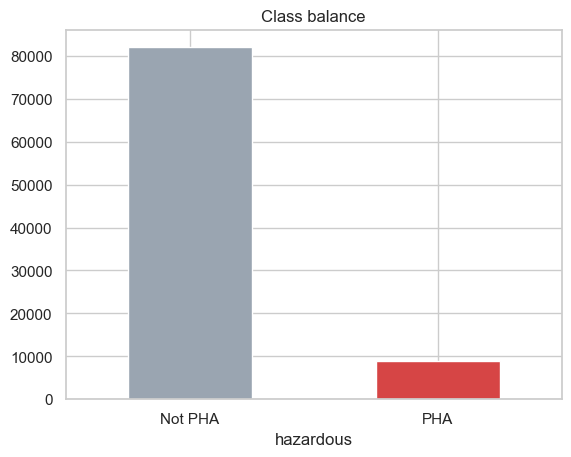

In [3]:
display(class_balance(df))
ax = df['hazardous'].map({0:'Not PHA',1:'PHA'}).value_counts().plot.bar(color=['#9aa5b1','#d64545'], rot=0)
ax.set_title('Class balance'); plt.show()

## 3. Distributions by class
PHAs are all bright/large (low H). Velocity and miss distance overlap heavily.

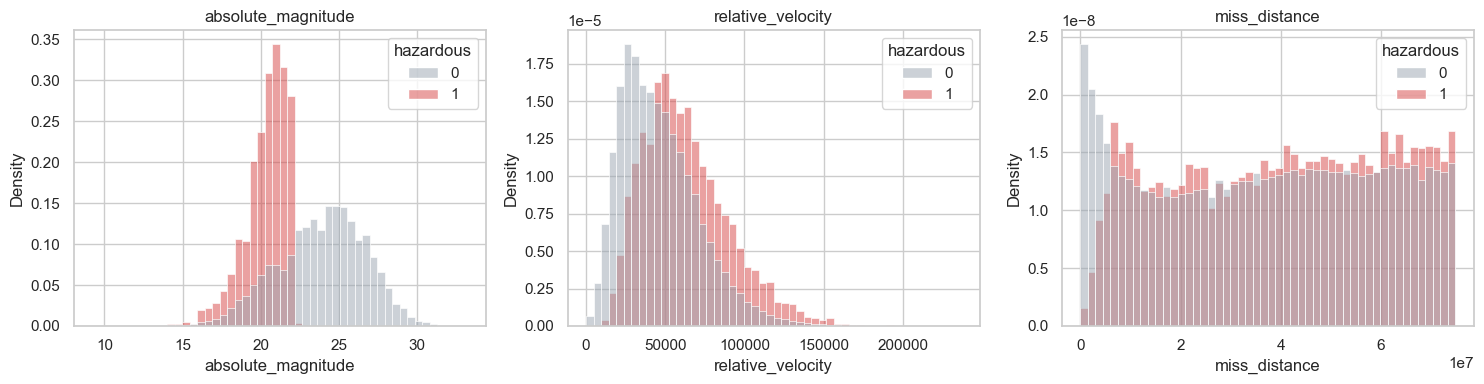

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, kw in zip(axes, ['absolute_magnitude','relative_velocity','miss_distance'], [{}, {}, {}]):
    sns.histplot(data=df, x=col, hue='hazardous', stat='density', common_norm=False, bins=50, ax=ax, palette=['#9aa5b1','#d64545'])
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [5]:
print(df.groupby('hazardous')['absolute_magnitude'].describe().round(2))
print('Share of PHAs with H <= 22.4:', (df.loc[df.hazardous==1,'absolute_magnitude']<=22.4).mean())

             count   mean   std    min    25%   50%    75%   max
hazardous                                                       
0          81996.0  23.87  2.80   9.23  22.06  24.1  25.90  33.2
1           8840.0  20.31  1.34  14.04  19.61  20.6  21.36  22.4
Share of PHAs with H <= 22.4: 1.0


## 4. Diameter is just H in disguise
The dataset's diameters are computed from H with a fixed formula, so they add *no* information. (Max log10 error vs the formula below.)

In [6]:
print('max |log10 error|:', diameter_h_formula_error(df))
print('diameter_max / diameter_min ratio:', (df.est_diameter_max/df.est_diameter_min).round(4).unique())

max |log10 error|: 2.285580043023014e-08
diameter_max / diameter_min ratio: [2.2361]


## 5. Correlation heatmap
H is strongly (negatively) correlated with the hazard label; flyby features are barely correlated with it.

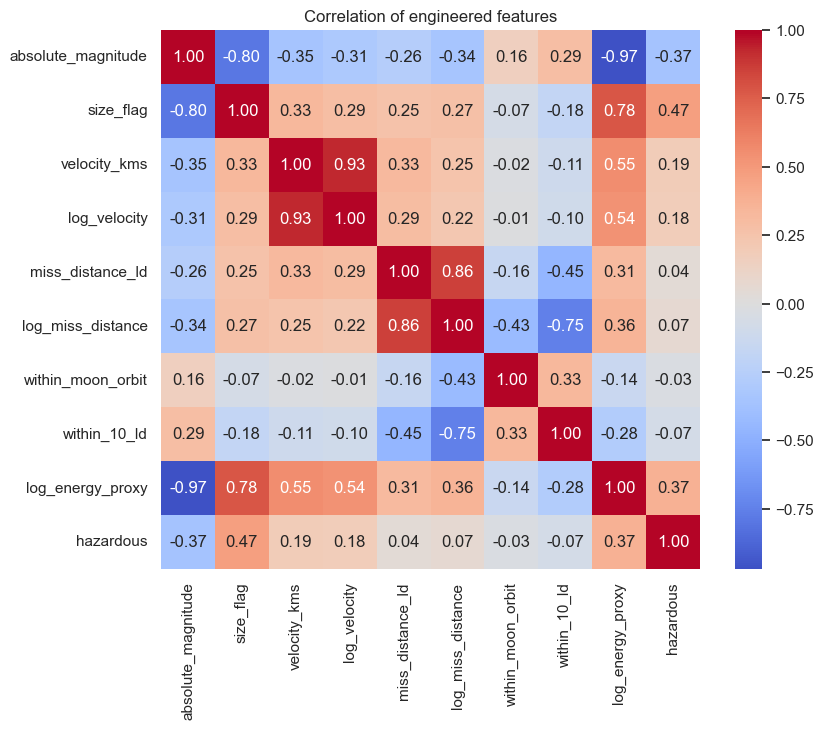

In [7]:
feat = add_features(df[['absolute_magnitude','relative_velocity','miss_distance']])
feat['hazardous'] = df['hazardous']
plt.figure(figsize=(9, 7))
sns.heatmap(feat.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation of engineered features'); plt.show()

## 6. Where do PHAs live? (H vs miss distance)
The orbital-element plot (a vs e) isn't possible: this dataset has no orbital elements. The closest equivalent is brightness vs approach distance. PHAs are confined to H <= 22 but sit throughout the distance range, which is why the problem is hard.

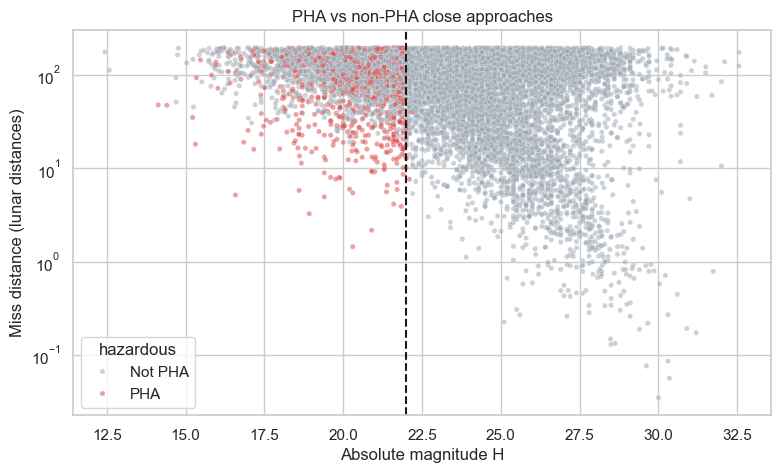

In [8]:
s = df.sample(10000, random_state=0)
plt.figure(figsize=(9, 5))
sns.scatterplot(x=s.absolute_magnitude, y=s.miss_distance/384400, hue=s.hazardous.map({0:'Not PHA',1:'PHA'}), alpha=.5, s=14, palette={'Not PHA':'#9aa5b1','PHA':'#d64545'})
plt.yscale('log'); plt.axvline(22, ls='--', c='k'); plt.xlabel('Absolute magnitude H'); plt.ylabel('Miss distance (lunar distances)')
plt.title('PHA vs non-PHA close approaches'); plt.show()

## 7. Hazard rate vs H
The key plot: the PHA share is ~30% for H <= 22 and ~0% above it. Being big enough is necessary, but not sufficient (the orbit's MOID, which we do not have, decides the rest).

In [9]:
b = pd.cut(df.absolute_magnitude, [0,16,18,20,21,22,23,25,40])
df.groupby(b, observed=True)['hazardous'].agg(['mean','size']).round(3)

,mean,size
absolute_magnitude,,
"(0, 16]",0.208,303
"(16, 18]",0.256,2023
"(18, 20]",0.274,9033
"(20, 21]",0.305,8464
"(21, 22]",0.336,9278
"(22, 23]",0.009,9503
"(23, 25]",0.000,22149
"(25, 40]",0.000,30083


## Takeaways
1. ~10% positives -> use PR-AUC and recall, stratified and *grouped* splits.
2. H carries most of the signal; diameters are redundant with H.
3. No MOID / orbital elements here, so a ceiling on achievable precision is expected. This is explained and quantified in the README.